  fecha_registro         planta  caudal_entrada_m3_d  DBO_entrada_mg_L  \
0     2025-08-17     Planta Sur                 6562               271   
1     2025-09-07     Planta Sur                 5336               322   
2     2025-07-26   Planta Norte                 5755               318   
3     2025-10-27  Planta Centro                 6840               216   
4     2025-09-06  Planta Centro                 6803               326   

   SST_entrada_mg_L  pH_entrada  energia_aeracion_kWh  lodos_generados_kg_d  \
0               324        7.12                1261.1                 440.3   
1               230        7.01                1629.3                 561.2   
2               282        6.79                1469.2                 441.6   
3               167        7.01                1764.8                 560.0   
4               200        7.55                1409.3                 654.0   

   DBO_salida_mg_L  cumplimiento_norma  
0             40.0                   0 

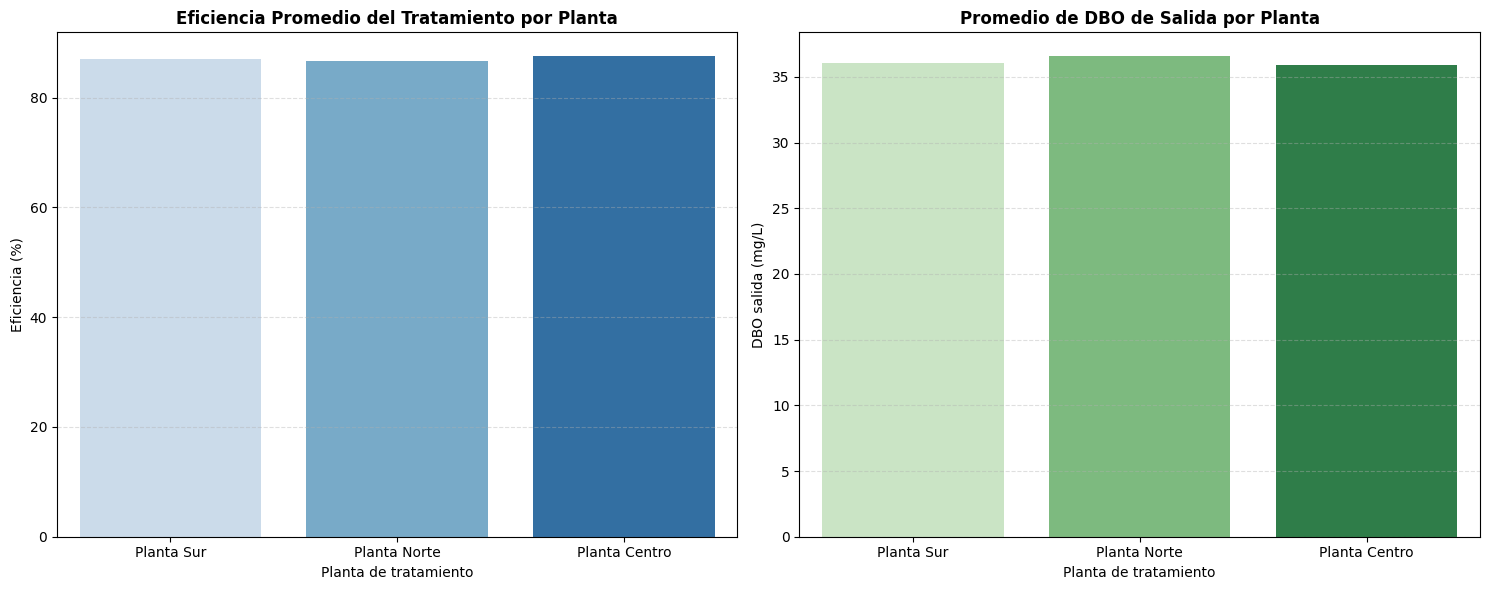

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/dataset_set_A_aguas_residuales.xlsx")

print(df.head())

print(df.info())

print(df.describe())

df["eficiencia_tratamiento"] = (
    (
        df["DBO_entrada_mg_L"] -
        df["DBO_salida_mg_L"]
    )
    / df["DBO_entrada_mg_L"]
) * 100

resumen_plantas = df.groupby("planta")[[
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "eficiencia_tratamiento",
    "caudal_entrada_m3_d"
]].mean()

print(resumen_plantas)

reporte_operaciones = df[[
    "fecha_registro",
    "planta",
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d"
]]

reporte_ambiental = df[[
    "fecha_registro",
    "planta",
    "DBO_salida_mg_L",
    "cumplimiento_norma"
]]

reporte_operaciones.to_excel(
    "../outputs/reporte_operaciones.xlsx",
    index=False
)

reporte_ambiental.to_excel(
    "../outputs/reporte_gestion_ambiental.xlsx",
    index=False
)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)

sns.barplot(
    data=df,
    x="planta",
    y="eficiencia_tratamiento",
    hue="planta",
    palette="Blues",
    legend=False,
    errorbar=None
)

plt.title(
    "Eficiencia Promedio del Tratamiento por Planta",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Planta de tratamiento")
plt.ylabel("Eficiencia (%)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.subplot(1, 2, 2)

sns.barplot(
    data=df,
    x="planta",
    y="DBO_salida_mg_L",
    hue="planta",
    palette="Greens",
    legend=False,
    errorbar=None
)

plt.title(
    "Promedio de DBO de Salida por Planta",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Planta de tratamiento")
plt.ylabel("DBO salida (mg/L)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("../outputs/dashboard.png")

plt.show()